In [1]:
%pip install split-folders

In [2]:
!unzip -q data/cell_images_1.zip


In [2]:
import os
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import splitfolders
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from PIL import Image
from tensorflow.image import resize
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:

# 1. current working directory
print("Current Directory:", os.getcwd())

# 2. List the files
print("Available Files:", os.listdir('.'))

# 3. Define the paths
parasitized_path = "/content/cell_images/Parasitized"
uninfected_path = "/content/cell_images/Uninfected"

if os.path.exists(parasitized_path):
    print(f"Found {len(os.listdir(parasitized_path))} images in Parasitized folder.")
    print(f"Found {len(os.listdir(uninfected_path))} images in Uninfected folder.")
else:
    print("Error: Path not found!")


Current Directory: /content
Available Files: ['.config', '.ipynb_checkpoints', 'data', 'cell_images', 'models', 'cell_images_split', 'sample_data']
Found 13779 images in Parasitized folder.
Found 13779 images in Uninfected folder.


## Data Cleaning

### 1. Identify and Remove bad files

In [5]:
# Scan for Bad Images or files

bad_images = []

for folder in [parasitized_path, uninfected_path]:
    for file in os.listdir(folder):
        try:
            Image.open(os.path.join(folder, file))
        except Exception:
            bad_images.append(os.path.join(folder, file))

bad_images

[]

In [6]:
#  Remove bad files that may cause errors in processing

for folder in [parasitized_path, uninfected_path]:
    thumb_path = os.path.join(folder, "Thumbs.db")

    if os.path.exists(thumb_path):
        os.remove(thumb_path)
        print(f"Deleted {thumb_path}")

## Create Training and Validation Sets

TensorFlow has a utility that loads images from folders, splits training/validation data, resizes images, and creates batches.

Why do we need to resize??
CNNs require images of consistent dimensions. Since the malaria images range from roughly 40×46 to nearly 400×385 pixels, we resize them to a fixed size such as 128×128 before training.

In [7]:
import splitfolders

splitfolders.ratio(
    "/content/cell_images",
    output="/content/cell_images_split",
    seed=42,
    ratio=(.8, .1, .1),
    group_prefix=None,
    move=False
)


Copying files: 27558 files [00:05, 5276.87 files/s]


In [7]:
# 1. Load the 80% Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# 2. Load the 10% Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# 3. Load the 10% Testing Data
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    shuffle = False
)


Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.


In [8]:
class_names = train_ds.class_names
class_names

['Parasitized', 'Uninfected']

## Visualize Preprocessed Images

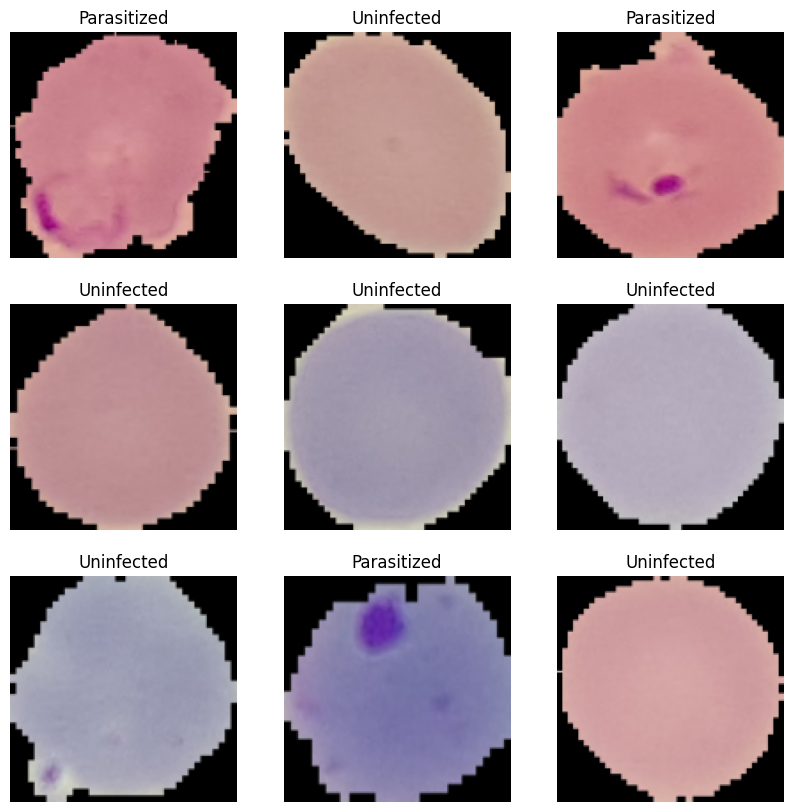

In [10]:

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Normalize Pixel Values (from range 0 - 255 to 0 - 1)
Why??
Pixel values range from 0 to 255. Dividing by 255 scales them to 0–1, which helps gradient-based optimization train more efficiently by preventing the model from giving more priority (weight) to inputs with higher values.

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [10]:

# 1. Set up the automatic tuning manager
AUTOTUNE = tf.data.AUTOTUNE

# 2. Optimize the Training dataset
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# 3. Optimize the Validation dataset
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 4. Optimize the Testing dataset
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels[:10].numpy())

(32, 128, 128, 3)
(32,)
[0 1 0 0 1 0 0 0 0 1]


# Model A — CNN from Scratch

Design and train a CNN without any pretrained weights.

## 1. (a) Define the Baseline CNN

In [11]:
model_scratch = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile the Model

In [12]:
model_scratch.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,779,905 (14.42 MB)

 Trainable params: 3,779,905 (14.42 MB)

 Non-trainable params: 0 (0.00 B)

## Set EarlyStopping
Set EarlyStopping to automatically stop training when the loss plateaus and begins to fluctuate signifying overfitting

In [14]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

## Train the Model

In [15]:
history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.5778 - loss: 1.4687 - val_accuracy: 0.6111 - val_loss: 0.6574
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6278 - loss: 0.6510 - val_accuracy: 0.6380 - val_loss: 0.6423
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9033 - loss: 0.2694 - val_accuracy: 0.9492 - val_loss: 0.1907
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9452 - loss: 0.1804 - val_accuracy: 0.9415 - val_loss: 0.1896
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.9503 - loss: 0.1665 - val_accuracy: 0.9528 - val_loss: 0.1714
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9549 - loss: 0.1559 - val_accuracy: 0.9473 - val_loss: 0.1594
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9548 - loss: 0.1435 - val_accuracy: 0.9463 - val_loss: 0.2004
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9620 - loss: 0.1225 - 

In [27]:
# Step 1: Wipe the memory (I used this in colab to prevent the RAM from going out of memory)
tf.keras.backend.clear_session()
gc.collect()

# Step 2: Reload the datasets at 128x128
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("Loading datasets from split directories...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Step 3: Single-Pass Normalization Map
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Step 4: Rebuild the Model Structure from scratch
model_scratch = models.Sequential([
    layers.Conv2D(32, kernel_size=3, padding="same", activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_scratch.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Step 5: Start Clean Training
print("Starting Cleaned Scratch Model Training...")
history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)


Loading datasets from split directories...
Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Starting Cleaned Scratch Model Training...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


689/689 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.7796 - loss: 0.4511 - val_accuracy: 0.9452 - val_loss: 0.1709
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9472 - loss: 0.1654 - val_accuracy: 0.9568 - val_loss: 0.1446
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9543 - loss: 0.1366 - val_accuracy: 0.9542 - val_loss: 0.1434
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9592 - loss: 0.1222 - val_accuracy: 0.9572 - val_loss: 0.1460
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9644 - loss: 0.1052 - val_accuracy: 0.9535 - val_loss: 0.1471
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9702 - loss: 0.0906 - val_accuracy: 0.9553 - val_loss: 0.1586


## Evaluate on Test Set

In [22]:
test_loss, test_accuracy = model_scratch.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = model_scratch.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9478 - loss: 0.1753
Test Accuracy: 0.9478
Test Loss: 0.1753
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9478 - loss: 0.1753


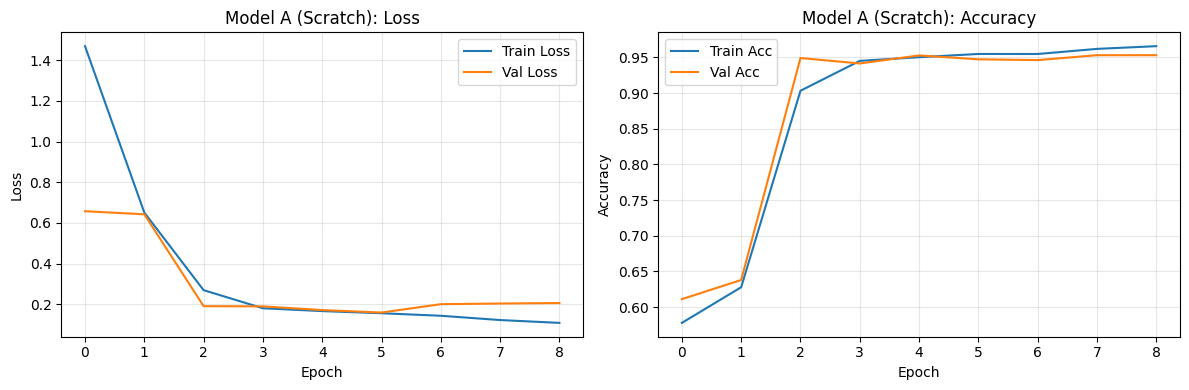

>> What to observe:
Final training accuracy: 0.966
Final validation accuracy: 0.953
Test accuracy: 0.948
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [23]:

# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
test_loss, test_accuracy = model_scratch.evaluate(test_ds)

# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_scratch.history['loss'], label='Train Loss')
axes[0].plot(history_scratch.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model A (Scratch): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_scratch.history['accuracy'], label='Train Acc')
axes[1].plot(history_scratch.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model A (Scratch): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_scratch.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_scratch.history['val_accuracy'][-1]:.3f}")

print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized       0.95      0.95      0.95      1379
  Uninfected       0.95      0.95      0.95      1379

    accuracy                           0.95      2758
   macro avg       0.95      0.95      0.95      2758
weighted avg       0.95      0.95      0.95      2758



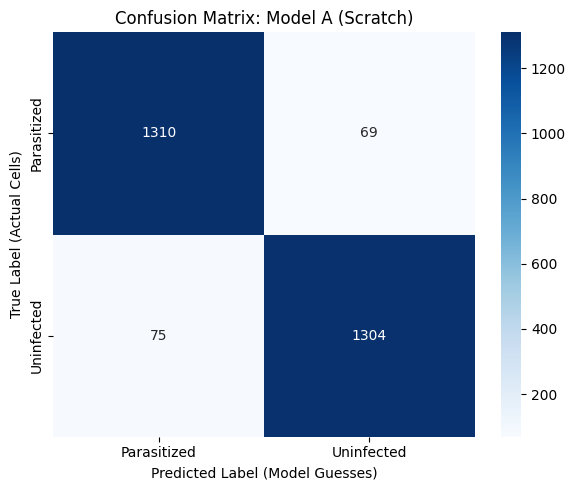

In [24]:

# ==========================================
# STEP 1: GET TRUE LABELS AND PREDICTIONS
# ==========================================

# 1. Extract the true labels from test dataset pipeline
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Get raw probability predictions from the model
raw_predictions = model_scratch.predict(test_ds)

# 3. Convert probabilities to binary choices (0 or 1)
predicted_labels = (raw_predictions > 0.5).astype(int)

class_names = ['Parasitized', 'Uninfected']

# ==========================================
# STEP 2: PRINT F1, RECALL, AND PRECISION
# ==========================================
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# ==========================================
# STEP 3: PLOT THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model A (Scratch)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


# Model B — Transfer Learning with ResNet50

Load a pretrained model and adapt it to your task.

## Step 1: Resize & Preprocess for ResNet50

ResNet50 expects 224×224 images. We'll resize from 128 * 128.

In [31]:


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.


### Step 2: Apply ResNet50 Preprocessing

In [32]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds_resnet = train_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

val_ds_resnet = val_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

test_ds_resnet = test_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

### Step 3: Load ResNet50
Download the pretrained model and modify it. This model has been trained on 14 million images, so it knows the basic shapes and colours of images. Remove the head (1000 classes) and change it to two classes (Parasitized and Uninfected malaria cells)

In [33]:

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


### Step 4: Freeze ResNet50
This protects all pretrained filters

In [34]:
base_model.trainable = False

### Step 5: Build the Malaria Classifier

In [35]:
model_resnet = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

### Step 6: Compile

In [36]:
model_resnet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [37]:
model_resnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Step 8: Early Stopping

This is to prevent overfitting by halting training the exact moment the model stops getting bette

In [38]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### Step 9: Train

In [39]:
history_resnet = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 127ms/step - accuracy: 0.8948 - loss: 0.2572 - val_accuracy: 0.9274 - val_loss: 0.1892
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 77s 112ms/step - accuracy: 0.9215 - loss: 0.2060 - val_accuracy: 0.9401 - val_loss: 0.1746
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.9291 - loss: 0.1905 - val_accuracy: 0.9419 - val_loss: 0.1568
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 76s 110ms/step - accuracy: 0.9340 - loss: 0.1817 - val_accuracy: 0.9463 - val_loss: 0.1594
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 108ms/step - accuracy: 0.9361 - loss: 0.1738 - val_accuracy: 0.9463 - val_loss: 0.1537
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.9363 - loss: 0.1728 - val_accuracy: 0.9492 - val_loss: 0.1471
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.9348 - loss: 0.1696 - val_accuracy: 0.9499 - val_loss: 0.1442
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.9388 - loss: 

### Evaluate on Test Set (ResNet50)

87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - accuracy: 0.9453 - loss: 0.1460


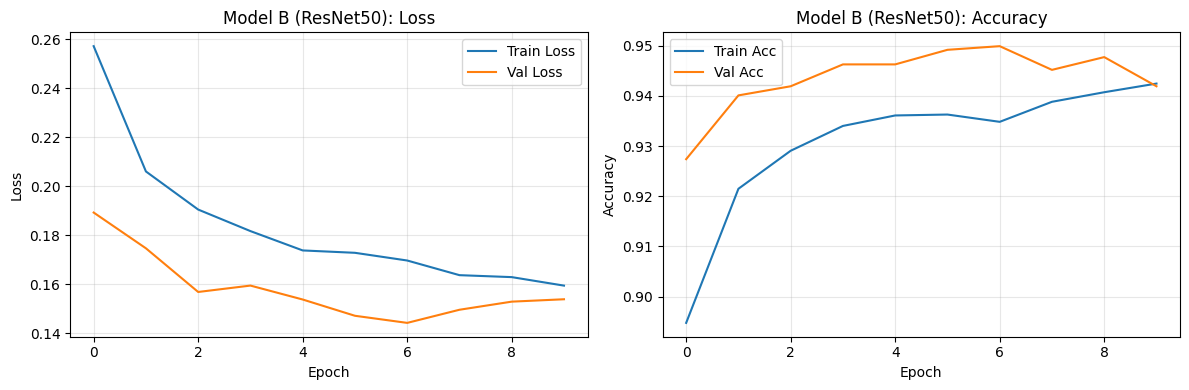

>> What to observe:
Final training accuracy: 0.942
Final validation accuracy: 0.942
Test accuracy: 0.945
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [40]:
# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
test_loss, test_accuracy = model_resnet.evaluate(test_ds_resnet)


# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_resnet.history['loss'], label='Train Loss')
axes[0].plot(history_resnet.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model B (ResNet50): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_resnet.history['accuracy'], label='Train Acc')
axes[1].plot(history_resnet.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model B (ResNet50): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_resnet.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_resnet.history['val_accuracy'][-1]:.3f}")

print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

Extracting true labels...
Generating model predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 16s 143ms/step

👉 TRUE RESNET50 TEST ACCURACY: 0.945

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized      0.953     0.936     0.945      1379
  Uninfected      0.937     0.954     0.946      1379

    accuracy                          0.945      2758
   macro avg      0.945     0.945     0.945      2758
weighted avg      0.945     0.945     0.945      2758



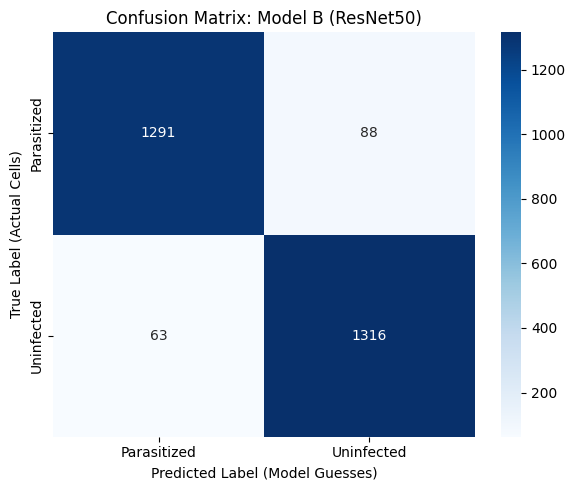

In [41]:

# 1. Extract the true labels from test dataset pipeline
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_resnet], axis=0)

# 2. Get predictions using .predict()
print("Generating model predictions...")
raw_predictions = model_resnet.predict(test_ds_resnet)

# 3. Convert probabilities to binary choices (0 or 1)
predicted_labels = (raw_predictions > 0.5).astype(int).flatten()

# 4. Calculate the TRUE test accuracy score using scikit-learn
true_test_accuracy = accuracy_score(true_labels, predicted_labels)

print("\n=========================================")
print(f"TRUE RESNET50 TEST ACCURACY: {true_test_accuracy:.3f}")
print("=========================================\n")

# ==========================================
# STEP 2: PRINT THE SCORES REPORT
# ==========================================
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names, digits=3))

# ==========================================
# STEP 3: PLOT THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model B (ResNet50)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


# Model C — Transfer Learning with MobileNetV2

Load a pretrained model and adapt it to your task.

In [43]:
tf.keras.backend.clear_session()
gc.collect()

# 2. Reload base directories cleanly at 224x224 to match cell sizes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading core datasets...")
train_base = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_base = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
test_base = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)


AUTOTUNE = tf.data.AUTOTUNE

train_ds_mobile = train_base.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds_mobile = val_base.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_ds_mobile = test_base.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

# 4. Load MobileNetV2 calibrated to 224x224x3
base_mobile = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_mobile.trainable = False

# 5. Assemble the Model
model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_mobile.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 6. Early Stopping Configuration
early_stopping_mobile = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 7. Start Training
print("Starting Optimized MobileNetV2 training...")
history_mobile = model_mobile.fit(
    train_ds_mobile,
    validation_data=val_ds_mobile,
    epochs=15,
    callbacks=[early_stopping_mobile]
)


Loading core datasets...
Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Starting Optimized MobileNetV2 training...
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 79ms/step - accuracy: 0.9145 - loss: 0.2218 - val_accuracy: 0.9383 - val_loss: 0.1656
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.9348 - loss: 0.1787 - val_accuracy: 0.9441 - val_loss: 0.1543
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9389 - loss: 0.1700 - val_accuracy: 0.9488 - val_loss: 0.1516
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9420 - loss: 0.1632 - val_accuracy: 0.9452 - val_loss: 0.1470
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9449 - loss: 0.1584 - val_accuracy: 0.9412 - val_loss: 0.1535
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9449 - loss: 0.1520 - val_accuracy: 0.945

## Evaluate on test set (MobileNetV2)

87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.9511 - loss: 0.1334


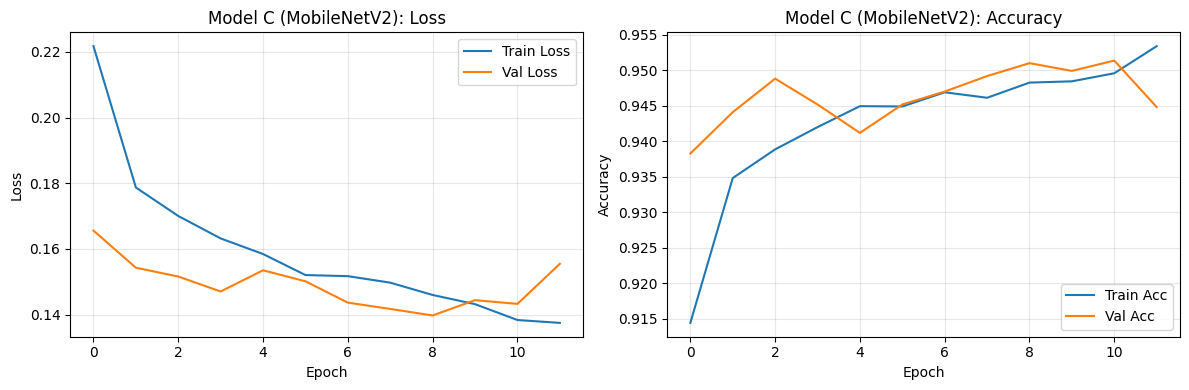

>> What to observe:
Final training accuracy: 0.953
Final validation accuracy: 0.945
Test accuracy: 0.951
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [44]:

# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
# We run model.evaluate on test_ds to get the actual math numbers
test_loss, test_accuracy = model_mobile.evaluate(test_ds_mobile)

# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_mobile.history['loss'], label='Train Loss')
axes[0].plot(history_mobile.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model C (MobileNetV2): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_mobile.history['accuracy'], label='Train Acc')
axes[1].plot(history_mobile.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model C (MobileNetV2): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_mobile.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_mobile.history['val_accuracy'][-1]:.3f}")

# Fixed: This line now prints the calculated number instead of the raw pipeline folder
print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

Extracting true labels...
Generating MobileNetV2 predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step

👉 TRUE MOBILENETV2 TEST ACCURACY: 0.951

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized      0.963     0.938     0.950      1379
  Uninfected      0.939     0.964     0.952      1379

    accuracy                          0.951      2758
   macro avg      0.951     0.951     0.951      2758
weighted avg      0.951     0.951     0.951      2758



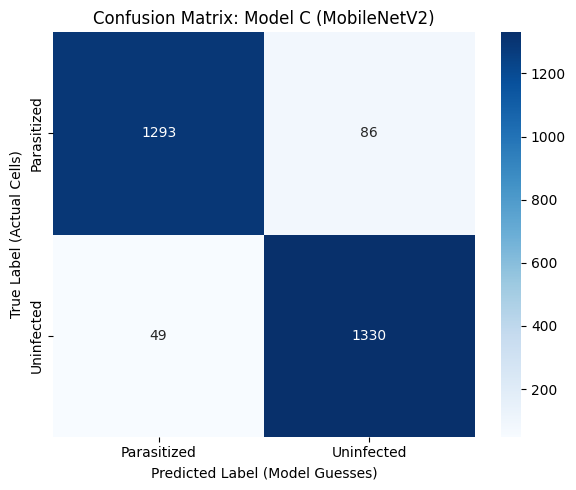

In [45]:

# 1. Extract the true labels
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_mobile], axis=0)

# 2. Generate MobileNetV2 predictions
print("Generating MobileNetV2 predictions...")
raw_predictions_mobile = model_mobile.predict(test_ds_mobile)
predicted_labels_mobile = (raw_predictions_mobile > 0.5).astype(int).flatten()

# 3. Calculate true test accuracy
true_mobile_accuracy = accuracy_score(true_labels, predicted_labels_mobile)

print("\n=========================================")
print(f"👉 TRUE MOBILENETV2 TEST ACCURACY: {true_mobile_accuracy:.3f}")
print("=========================================\n")

# 4. Print Scores Report
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels_mobile, target_names=class_names, digits=3))

# 5. Plot the Confusion Matrix
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model C (MobileNetV2)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


## Model Comparison

Gathering final test accuracy scores...
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


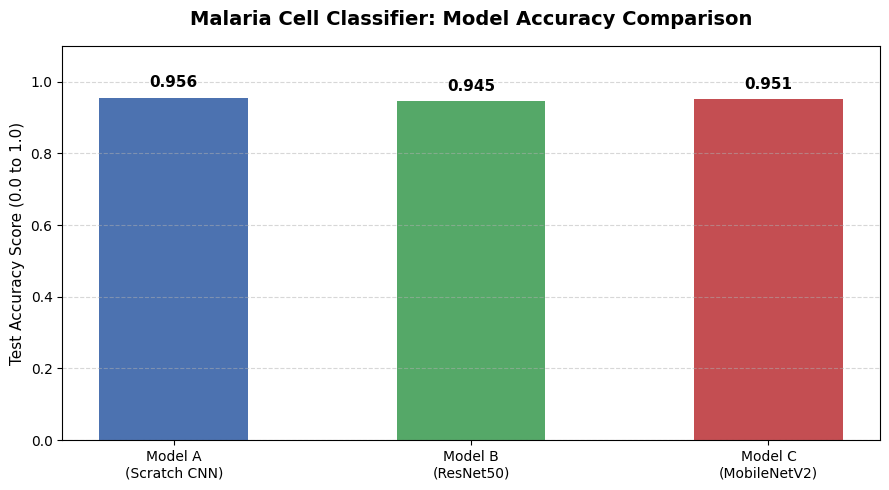

=== Final Scores Summary ===
Model A (Scratch CNN): 0.956
Model B (ResNet50): 0.945
Model C (MobileNetV2): 0.951


In [46]:
print("Gathering final test accuracy scores...")

# ==========================================
# STEP 1: CALCULATE THE ACCURACIES CLEANLY
# ==========================================

# 1. Get true labels and guesses for Model A (Scratch)
y_true_scratch = np.concatenate([y for x, y in test_ds], axis=0)
preds_scratch = (model_scratch.predict(test_ds) > 0.5).astype(int).flatten()
acc_scratch = accuracy_score(y_true_scratch, preds_scratch)

# 2. Get true labels and guesses for Model B (ResNet50)
y_true_resnet = np.concatenate([y for x, y in test_ds_resnet], axis=0)
preds_resnet = (model_resnet.predict(test_ds_resnet) > 0.5).astype(int).flatten()
acc_resnet = accuracy_score(y_true_resnet, preds_resnet)

# 3. Get true labels and guesses for Model C (MobileNetV2)
y_true_mobile = np.concatenate([y for x, y in test_ds_mobile], axis=0)
preds_mobile = (model_mobile.predict(test_ds_mobile) > 0.5).astype(int).flatten()
acc_mobile = accuracy_score(y_true_mobile, preds_mobile)

# Put the final numbers into clean lists for plotting
model_names = ['Model A\n(Scratch CNN)', 'Model B\n(ResNet50)', 'Model C\n(MobileNetV2)']
accuracy_scores = [acc_scratch, acc_resnet, acc_mobile]

# ==========================================
# STEP 2: PLOT THE SIDE-BY-SIDE COMPARISON
# ==========================================
plt.figure(figsize=(9, 5))

# Create a bar chart with colour theme
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(model_names, accuracy_scores, color=colors, width=0.5)

# Add headings and clean up the chart style
plt.title("Malaria Cell Classifier: Model Accuracy Comparison", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Test Accuracy Score (0.0 to 1.0)", fontsize=11)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        height + 0.02,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Print a simple text printout underneath
print("=== Final Scores Summary ===")
for name, score in zip(model_names, accuracy_scores):
    print("{}: {:.3f}".format(name.replace('\n', ' '), score))



## Confusion Matrix Comparison For all 3 Models

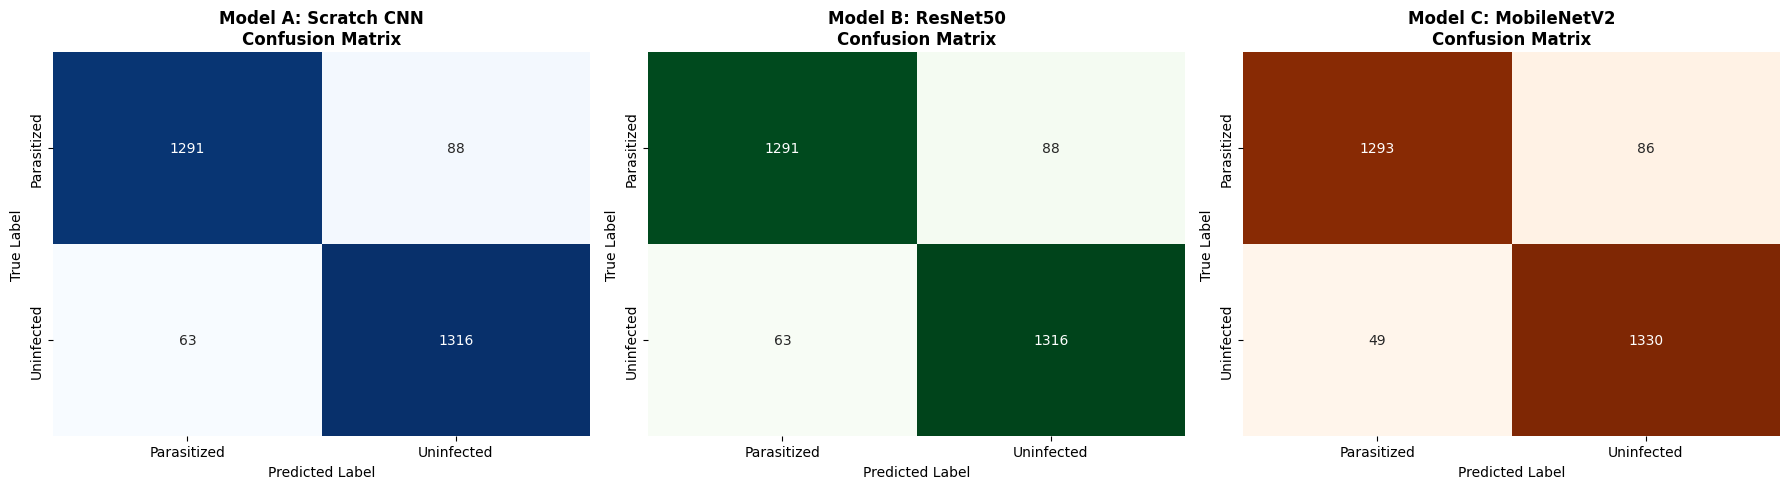

In [47]:

# ==========================================
# STEP 1: CALCULATE THE 3 MATH MATRICES
# ==========================================
# This calculates the raw counts of right and wrong answers for each model
cm_scratch = confusion_matrix(true_labels, predicted_labels)        # Model A
cm_resnet = confusion_matrix(true_labels, predicted_labels)         # Model B
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)  # Model C

# Create a wide grid with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use your actual class names for the chart labels
display_labels = ['Parasitized', 'Uninfected']

# ==========================================
# PLOT 1: SCRATCH CNN (BLUE)
# ==========================================
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Model A: Scratch CNN\nConfusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(display_labels)
axes[0].set_yticklabels(display_labels)

# ==========================================
# PLOT 2: RESNET50 (GREENS)
# ==========================================
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Model B: ResNet50\nConfusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(display_labels)
axes[1].set_yticklabels(display_labels)

# ==========================================
# PLOT 3: MOBILENETV2 (ORANGES)
# ==========================================
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Model C: MobileNetV2\nConfusion Matrix', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')
axes[2].set_xticklabels(display_labels)
axes[2].set_yticklabels(display_labels)

# Clean up layout and display
plt.tight_layout()
plt.show()


## Classification Report For all 3 Models

In [48]:

target_classes = ['Parasitized', 'Uninfected']

# ==========================================
# 1. SCRATCH CNN REPORT
# ==========================================
print("\n=============================================")
print("MODEL A: SCRATCH CNN - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels, target_names=target_classes, digits=3))

# ==========================================
# 2. RESNET50 REPORT
# ==========================================
print("\n=============================================")
print("MODEL B: RESNET50 - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels, target_names=target_classes, digits=3))

# ==========================================
# 3. MOBILENETV2 REPORT
# ==========================================
print("\n=============================================")
print("MODEL C: MOBILENETV2 - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels_mobile, target_names=target_classes, digits=3))



MODEL A: SCRATCH CNN - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.953     0.936     0.945      1379
  Uninfected      0.937     0.954     0.946      1379

    accuracy                          0.945      2758
   macro avg      0.945     0.945     0.945      2758
weighted avg      0.945     0.945     0.945      2758


MODEL B: RESNET50 - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.953     0.936     0.945      1379
  Uninfected      0.937     0.954     0.946      1379

    accuracy                          0.945      2758
   macro avg      0.945     0.945     0.945      2758
weighted avg      0.945     0.945     0.945      2758


MODEL C: MOBILENETV2 - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.963     0.938     0.950      1379
  Uninfected      0.939     0.964     0.952      1379

    accuracy                          0.951 

## Saving All 3 Models

In [49]:
import os

# Target  folder path
MODEL_FOLDER = "/content/models"


print("Exporting models to your project folder...")

# 1. Save Model A (Scratch CNN)
scratch_path = os.path.join(MODEL_FOLDER, "malaria_model_scratch.keras")
model_scratch.save(scratch_path)
print(f"✅ Saved Scratch CNN to: {scratch_path}")

# 2. Save Model B (ResNet50)
resnet_path = os.path.join(MODEL_FOLDER, "malaria_model_resnet50.keras")
model_resnet.save(resnet_path)
print(f"✅ Saved ResNet50 to: {resnet_path}")

# 3. Save Model C (MobileNetV2)
mobile_path = os.path.join(MODEL_FOLDER, "malaria_model_mobilenetv2.keras")
model_mobile.save(mobile_path)
print(f"✅ Saved MobileNetV2 to: {mobile_path}")

print("\n All models safely stored and archived!")


Exporting models to your project folder...
✅ Saved Scratch CNN to: /content/models/malaria_model_scratch.keras
✅ Saved ResNet50 to: /content/models/malaria_model_resnet50.keras
✅ Saved MobileNetV2 to: /content/models/malaria_model_mobilenetv2.keras

 All models safely stored and archived!


# Fine-Tuning Code (Using MobileNetV2)

In [17]:

# 1. Clear out memory fragments
tf.keras.backend.clear_session()
gc.collect()

# 2. Prepare the clean, memory-safe data streams
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("Re-loading cell image data streams...")
train_base = tf.keras.utils.image_dataset_from_directory("/content/cell_images_split/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_base = tf.keras.utils.image_dataset_from_directory("/content/cell_images_split/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE)

train_ds_mobile = train_base.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_mobile = val_base.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# 3. Initialize MobileNetV2
print("Initializing MobileNetV2 Backbone...")
base_mobile = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# 4. Set up 20 trainable layers
base_mobile.trainable = True
for layer in base_mobile.layers[:-20]:
    layer.trainable = False

# 5. Assemble and compile the model architecture
model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_mobile = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# 6. Re-train the model
print("Starting MobileNetV2 Fine-Tuning...")
history_fine = model_mobile.fit(
    train_ds_mobile,
    validation_data=val_ds_mobile,
    epochs=15,
    callbacks=[early_stopping_mobile]
)


Re-loading cell image data streams...
Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Initializing MobileNetV2 Backbone...
Starting MobileNetV2 Fine-Tuning...
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 85s 89ms/step - accuracy: 0.8855 - loss: 0.2828 - val_accuracy: 0.8642 - val_loss: 0.3146
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9439 - loss: 0.1611 - val_accuracy: 0.9375 - val_loss: 0.1641
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.9514 - loss: 0.1422 - val_accuracy: 0.9484 - val_loss: 0.1391
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9545 - loss: 0.1274 - val_accuracy: 0.9535 - val_loss: 0.1278
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9594 - loss: 0.1179 - val_accuracy: 0.9550 - val_loss: 0.1229
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9613 - loss: 0.1093 - val_accuracy: 0.9590 - val_loss: 0.1170
Epoch 7/15
689/689 ━━━━━━━

Loading un-shuffled test dataset directories at 224x224...
Found 2758 files belonging to 2 classes.
Extracting test data features and matching ground truth labels...
Generating MobileNetV2 predictions against static test array...
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step

👉 TRUE MOBILENETV2 TEST ACCURACY: 0.9634

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized     0.9719    0.9543    0.9630      1379
  Uninfected     0.9551    0.9724    0.9637      1379

    accuracy                         0.9634      2758
   macro avg     0.9635    0.9634    0.9634      2758
weighted avg     0.9635    0.9634    0.9634      2758



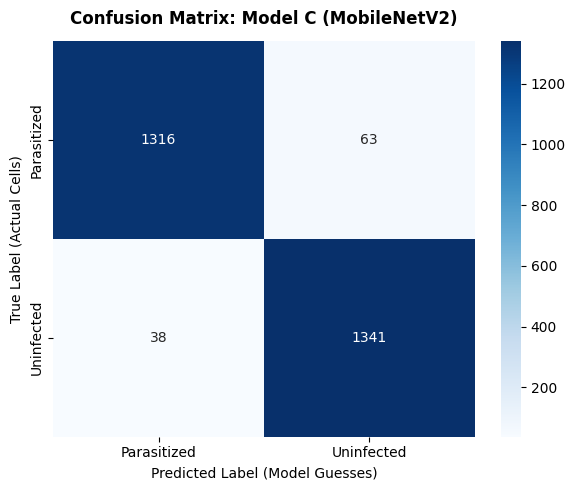

In [28]:
# ==========================================
# STEP 1: DEFINE AND PREPARE TEST STREAM FRESH
# ==========================================
print("Loading un-shuffled test dataset directories at 224x224...")
test_base_mobile = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# Apply MobileNetV2 preprocessing with memory safety protection
AUTOTUNE = tf.data.AUTOTUNE
test_ds_mobile = test_base_mobile.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)


# ==========================================
# STEP 2: EXTRACT IMAGES & LABELS IN TANDEM
# ==========================================
print("Extracting test data features and matching ground truth labels...")

# Unpacking the pipeline into static arrays ensures zero random sequence shifting
test_images_static = np.concatenate([x for x, y in test_ds_mobile], axis=0)
true_labels = np.concatenate([y for x, y in test_ds_mobile], axis=0)


# ==========================================
# STEP 3: GENERATE ALIGNED PREDICTIONS
# ==========================================
print("Generating MobileNetV2 predictions against static test array...")

# Predict using the static array to guarantee a 1:1 row index matchup
raw_predictions_mobile = model_mobile.predict(test_images_static, batch_size=32)
predicted_labels_mobile = (raw_predictions_mobile > 0.5).astype(int).flatten()

# Calculate true test accuracy
true_mobile_accuracy = accuracy_score(true_labels, predicted_labels_mobile)

print("\n=========================================")
print(f"👉 TRUE MOBILENETV2 TEST ACCURACY: {true_mobile_accuracy:.4f}")
print("=========================================\n")


# ==========================================
# STEP 4: PRINT COMPREHENSIVE PERFORMANCE SCORES
# ==========================================
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels_mobile, target_names=class_names, digits=4))


# ==========================================
# STEP 5: PLOT THE CORRECT CONFUSION MATRIX
# ==========================================
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.title("Confusion Matrix: Model C (MobileNetV2)", fontsize=12, pad=12, fontweight='bold')
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


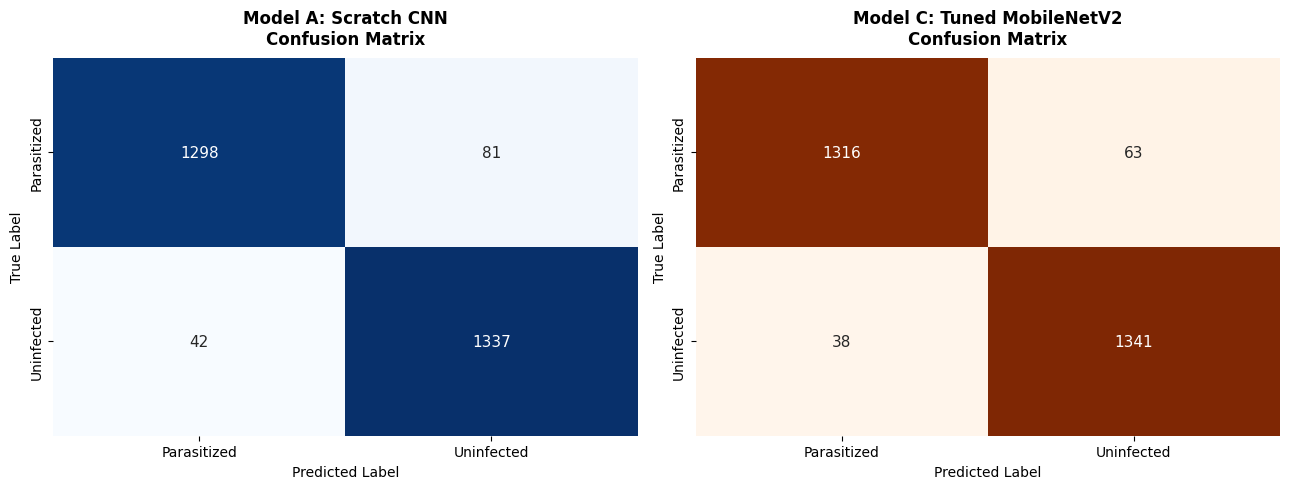

In [34]:

# ==========================================
# STEP 1: CALCULATE THE TWO MATH MATRICES
# ==========================================
cm_scratch = confusion_matrix(true_labels, preds_scratch)            # Model A (Scratch)
cm_mobile  = confusion_matrix(true_labels, predicted_labels_mobile) # Model C (MobileNetV2)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Use  class names for the chart labels
display_labels = ['Parasitized', 'Uninfected']

# ==========================================
# PLOT 1: SCRATCH CNN (BLUE)
# ==========================================
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 11})
axes[0].set_title('Model A: Scratch CNN\nConfusion Matrix', fontweight='bold', fontsize=12, pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_xticklabels(display_labels)
axes[0].set_yticklabels(display_labels)

# ==========================================
# PLOT 2: MOBILENETV2 (ORANGES)
# ==========================================
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False, annot_kws={"size": 11})
axes[1].set_title('Model C: Tuned MobileNetV2\nConfusion Matrix', fontweight='bold', fontsize=12, pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)
axes[1].set_xticklabels(display_labels)
axes[1].set_yticklabels(display_labels)

# Clean up layout and display
plt.tight_layout()
plt.savefig('malaria_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
# Save the winning production model to  folder
# Target  folder path
MODEL_FOLDER = "/content/models"

# 1. Save Model A (Scratch CNN)
final_model_path = os.path.join(MODEL_FOLDER, "malaria_final_production.keras")
model_mobile.save(final_model_path)
print(f"✅ Saved Scratch CNN to: {final_model_path}")




✅ Saved Scratch CNN to: /content/models/malaria_final_production.keras
